In [57]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import numpy as np
from scipy.stats import chi2_contingency
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

In [58]:
def open_file(file_path) -> pd.DataFrame:
    """Opens a file and returns the contents as DataFrame"""
    try:
        df = pd.read_csv(file_path)
    except FileNotFoundError:
        print(f"File {file_path} not found.")
        return None
    return df

df = open_file("US-pumpkins.csv")
df

,City Name,Type,Package,Variety,Sub Variety,Grade,Date,Low Price,High Price,Mostly Low,...,Unit of Sale,Quality,Condition,Appearance,Storage,Crop,Repack,Trans Mode,Unnamed: 24,Unnamed: 25
0,BALTIMORE,NaN,24 inch bins,NaN,NaN,NaN,4/29/17,270.00,280.00,270.0,...,NaN,NaN,NaN,NaN,NaN,NaN,E,NaN,NaN,NaN
1,BALTIMORE,NaN,24 inch bins,NaN,NaN,NaN,5/6/17,270.00,280.00,270.0,...,NaN,NaN,NaN,NaN,NaN,NaN,E,NaN,NaN,NaN
2,BALTIMORE,NaN,24 inch bins,HOWDEN TYPE,NaN,NaN,9/24/16,160.00,160.00,160.0,...,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN
3,BALTIMORE,NaN,24 inch bins,HOWDEN TYPE,NaN,NaN,9/24/16,160.00,160.00,160.0,...,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN
4,BALTIMORE,NaN,24 inch bins,HOWDEN TYPE,NaN,NaN,11/5/16,90.00,100.00,90.0,...,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1752,ST. LOUIS,NaN,22 lb cartons,MINIATURE,FLAT TYPE,NaN,9/30/16,14.75,14.75,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,LOWER.
1753,ST. LOUIS,NaN,36 inch bins,MINIATURE,ROUND TYPE,NaN,9/26/16,275.00,275.00,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,LOWER.
1754,ST. LOUIS,NaN,36 inch bins,MINIATURE,ROUND TYPE,NaN,9/27/16,275.00,275.00,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,STEADY.
1755,ST. LOUIS,NaN,36 inch bins,MINIATURE,ROUND TYPE,NaN,9/28/16,275.00,275.00,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,ABOUT STEADY.


In [59]:
def data_describe(df: pd.DataFrame) -> pd.DataFrame:
    """Function to retunr statistics about data"""
    overall_stat = df.describe()
    d_types = df.dtypes
    shape = df.shape
    null_values = df.isnull().sum()

    print("Overall Statistics:")
    print("=" * 90)
    print(overall_stat)
    print("\nData Types:")
    print(d_types)
    print("\nShape:")
    print(shape)
    print("\nNull Values:")
    print(null_values)


In [60]:
data_describe(df)

Overall Statistics:
       Grade    Low Price   High Price   Mostly Low  Mostly High  Environment  \
count    0.0  1757.000000  1757.000000  1654.000000  1654.000000          0.0   
mean     NaN   124.571338   132.970939   128.170550   132.491802          NaN   
std      NaN    83.876591    89.524958    86.512161    88.442967          NaN   
min      NaN     0.240000     0.240000     0.240000     0.240000          NaN   
25%      NaN    24.000000    24.500000    24.625000    26.125000          NaN   
50%      NaN   140.000000   150.000000   147.000000   150.000000          NaN   
75%      NaN   180.000000   200.000000   185.000000   200.000000          NaN   
max      NaN   480.000000   480.000000   480.000000   480.000000          NaN   

       Quality  Condition  Appearance  Storage  Crop  Trans Mode  Unnamed: 24  
count      0.0        0.0         0.0      0.0   0.0         0.0          0.0  
mean       NaN        NaN         NaN      NaN   NaN         NaN          NaN  
std       

In [61]:
total_df = len(df)
missing = df.isnull().sum()

percentage_missing = missing/total_df * 100
print(f"% Missing data per column: {percentage_missing.round(2)}")

% Missing data per column: City Name            0.00
Type                97.44
Package              0.00
Variety              0.28
Sub Variety         83.15
Grade              100.00
Date                 0.00
Low Price            0.00
High Price           0.00
Mostly Low           5.86
Mostly High          5.86
Origin               0.17
Origin District     92.54
Item Size           15.88
Color               35.06
Environment        100.00
Unit of Sale        90.78
Quality            100.00
Condition          100.00
Appearance         100.00
Storage            100.00
Crop               100.00
Repack               0.00
Trans Mode         100.00
Unnamed: 24        100.00
Unnamed: 25         94.14
dtype: float64


In [62]:
## Dropping 90 - 100 % missing data
to_drop = percentage_missing[percentage_missing >= 90].index

df_cleaned = df.drop(columns=to_drop)

In [63]:
df_cleaned

,City Name,Package,Variety,Sub Variety,Date,Low Price,High Price,Mostly Low,Mostly High,Origin,Item Size,Color,Repack
0,BALTIMORE,24 inch bins,NaN,NaN,4/29/17,270.00,280.00,270.0,280.0,MARYLAND,lge,NaN,E
1,BALTIMORE,24 inch bins,NaN,NaN,5/6/17,270.00,280.00,270.0,280.0,MARYLAND,lge,NaN,E
2,BALTIMORE,24 inch bins,HOWDEN TYPE,NaN,9/24/16,160.00,160.00,160.0,160.0,DELAWARE,med,ORANGE,N
3,BALTIMORE,24 inch bins,HOWDEN TYPE,NaN,9/24/16,160.00,160.00,160.0,160.0,VIRGINIA,med,ORANGE,N
4,BALTIMORE,24 inch bins,HOWDEN TYPE,NaN,11/5/16,90.00,100.00,90.0,100.0,MARYLAND,lge,ORANGE,N
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1752,ST. LOUIS,22 lb cartons,MINIATURE,FLAT TYPE,9/30/16,14.75,14.75,NaN,NaN,ILLINOIS,NaN,WHITE,N
1753,ST. LOUIS,36 inch bins,MINIATURE,ROUND TYPE,9/26/16,275.00,275.00,NaN,NaN,MICHIGAN,sml,NaN,N
1754,ST. LOUIS,36 inch bins,MINIATURE,ROUND TYPE,9/27/16,275.00,275.00,NaN,NaN,MICHIGAN,sml,NaN,N
1755,ST. LOUIS,36 inch bins,MINIATURE,ROUND TYPE,9/28/16,275.00,275.00,NaN,NaN,MICHIGAN,sml,NaN,N


In [64]:
df_cleaned["Variety"] = df_cleaned["Variety"].bfill()
df_cleaned["Sub Variety"] = df_cleaned["Sub Variety"].bfill()

In [65]:
df_cleaned

,City Name,Package,Variety,Sub Variety,Date,Low Price,High Price,Mostly Low,Mostly High,Origin,Item Size,Color,Repack
0,BALTIMORE,24 inch bins,HOWDEN TYPE,FLAT TYPE,4/29/17,270.00,280.00,270.0,280.0,MARYLAND,lge,NaN,E
1,BALTIMORE,24 inch bins,HOWDEN TYPE,FLAT TYPE,5/6/17,270.00,280.00,270.0,280.0,MARYLAND,lge,NaN,E
2,BALTIMORE,24 inch bins,HOWDEN TYPE,FLAT TYPE,9/24/16,160.00,160.00,160.0,160.0,DELAWARE,med,ORANGE,N
3,BALTIMORE,24 inch bins,HOWDEN TYPE,FLAT TYPE,9/24/16,160.00,160.00,160.0,160.0,VIRGINIA,med,ORANGE,N
4,BALTIMORE,24 inch bins,HOWDEN TYPE,FLAT TYPE,11/5/16,90.00,100.00,90.0,100.0,MARYLAND,lge,ORANGE,N
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1752,ST. LOUIS,22 lb cartons,MINIATURE,FLAT TYPE,9/30/16,14.75,14.75,NaN,NaN,ILLINOIS,NaN,WHITE,N
1753,ST. LOUIS,36 inch bins,MINIATURE,ROUND TYPE,9/26/16,275.00,275.00,NaN,NaN,MICHIGAN,sml,NaN,N
1754,ST. LOUIS,36 inch bins,MINIATURE,ROUND TYPE,9/27/16,275.00,275.00,NaN,NaN,MICHIGAN,sml,NaN,N
1755,ST. LOUIS,36 inch bins,MINIATURE,ROUND TYPE,9/28/16,275.00,275.00,NaN,NaN,MICHIGAN,sml,NaN,N


In [66]:
df_cleaned["Color"] = df_cleaned["Color"].replace("STRIPED", np.nan)

In [67]:
def central_tendency(df):
    """
    Returns the mean, mode, and median for each column in the DataFrame.
    """
    return {
            "mean": df.mean().round(2),
            "mode": df.mode().iloc[0],
            "median" : df.median().round(2)
        }

stats = central_tendency(df_cleaned[["Mostly Low", "Mostly High"]])
df_cleaned[["Mostly Low", "Mostly High"]] = df_cleaned[["Mostly Low", "Mostly High"]].fillna(stats['mean'])

In [68]:
def central_tendency_categorical(df):
    """Returns the mode for each column in the DataFrame."""
    return {
        "mode": df.mode().iloc[0]
    }

mode_stats = central_tendency_categorical(df_cleaned[["Origin", "Item Size", "Color"]])
df_cleaned[["Origin", "Item Size", "Color"]] = df_cleaned[["Origin", "Item Size", "Color"]].fillna(mode_stats["mode"])

In [ ]:
df_cleaned["Date"] = pd.to_datetime(df_cleaned["Date"], errors='coerce')
df_cleaned.info()

In [70]:
columns = ["City Name","Package","Variety","Sub Variety","Origin","Item Size","Color", "Repack"]
df_cleaned[columns] = df_cleaned[columns].astype("category")

In [71]:
df_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1757 entries, 0 to 1756
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   City Name    1757 non-null   category      
 1   Package      1757 non-null   category      
 2   Variety      1757 non-null   category      
 3   Sub Variety  1757 non-null   category      
 4   Date         1757 non-null   datetime64[ns]
 5   Low Price    1757 non-null   float64       
 6   High Price   1757 non-null   float64       
 7   Mostly Low   1757 non-null   float64       
 8   Mostly High  1757 non-null   float64       
 9   Origin       1757 non-null   category      
 10  Item Size    1757 non-null   category      
 11  Color        1757 non-null   category      
 12  Repack       1757 non-null   category      
dtypes: category(8), datetime64[ns](1), float64(4)
memory usage: 85.6 KB


In [72]:
def grouping(df: pd.Series):
    return df.value_counts()

In [73]:
print(grouping(df_cleaned["City Name"]))
print("=" * 20)
print(grouping(df_cleaned["Variety"]))

City Name
BOSTON           352
COLUMBIA         263
CHICAGO          248
SAN FRANCISCO    166
BALTIMORE        153
DALLAS           137
NEW YORK         112
ST. LOUIS        103
LOS ANGELES       62
ATLANTA           57
PHILADELPHIA      57
DETROIT           44
MIAMI              3
Name: count, dtype: int64
Variety
HOWDEN TYPE                 547
PIE TYPE                    468
MINIATURE                   310
FAIRYTALE                   132
CINDERELLA                   81
BIG MACK TYPE                74
MIXED HEIRLOOM VARIETIES     57
HOWDEN WHITE TYPE            49
KNUCKLE HEAD                 20
BLUE TYPE                    19
Name: count, dtype: int64


In [74]:
print(grouping(df["Sub Variety"]))
print("=" * 20)
print(grouping(df["Color"]))
print("=" * 20)
print(grouping(df["Item Size"]))

Sub Variety
FLAT TYPE     212
ROUND TYPE     84
Name: count, dtype: int64
Color
ORANGE     916
WHITE      213
STRIPED     12
Name: count, dtype: int64
Item Size
sml        363
med        337
lge        295
xlge       205
med-lge    133
jbo        128
exjbo       17
Name: count, dtype: int64


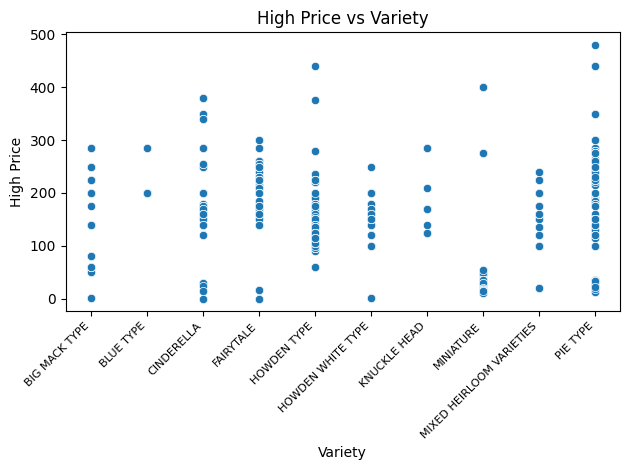

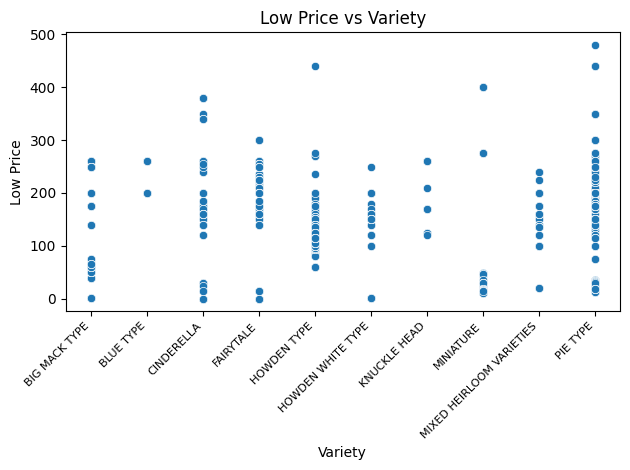

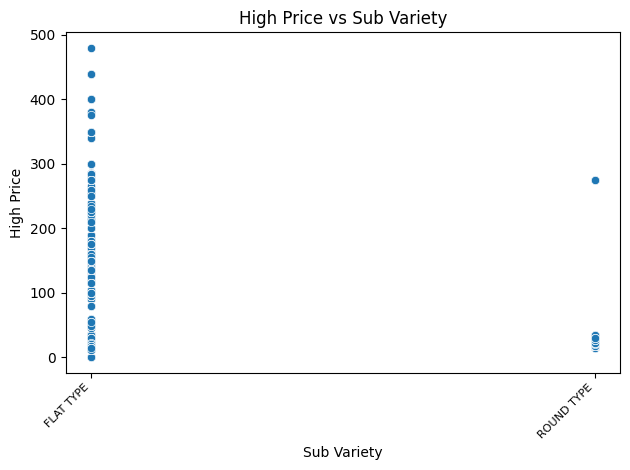

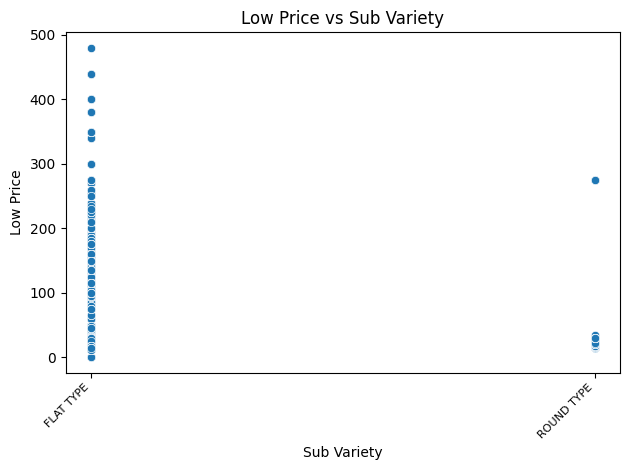

In [75]:
x_columns = ["Variety", "Sub Variety"]
y_columns = ["High Price", "Low Price"]

for x_col in x_columns:
    for y_col in y_columns:
        sns.scatterplot(data=df_cleaned, x=x_col, y=y_col)
        plt.xticks(rotation=45, ha='right', fontsize=8)
        plt.title(f"{y_col} vs {x_col}")
        plt.tight_layout()
        plt.show()

even if prices were high or low, people still bought flat type pumpkins

The prices of the different verieties of pumkins are between 100-300 dollars


In [76]:
df_cleaned.isnull().sum()

City Name      0
Package        0
Variety        0
Sub Variety    0
Date           0
Low Price      0
High Price     0
Mostly Low     0
Mostly High    0
Origin         0
Item Size      0
Color          0
Repack         0
dtype: int64

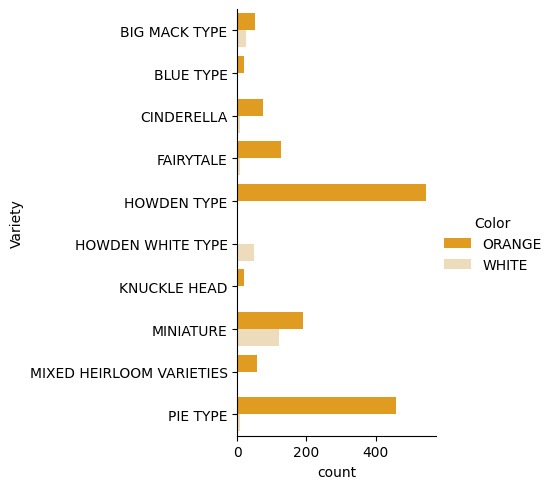

In [77]:
color_palette = {
    "ORANGE": "orange",
    "WHITE": "wheat"
}
sns.catplot(
    data=df_cleaned, y="Variety", hue="Color", kind="count",
    palette=color_palette
)
plt.show()

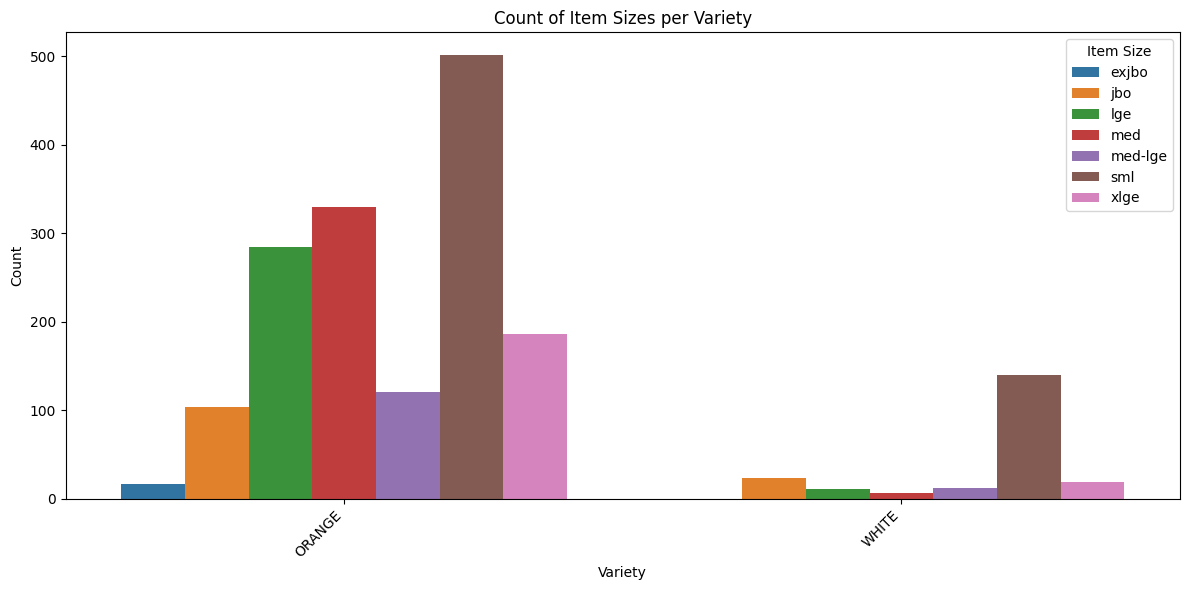

In [78]:
plt.figure(figsize=(12, 6))
sns.countplot(data=df_cleaned, x="Color", hue="Item Size")
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.xlabel("Variety")
plt.ylabel("Count")
plt.title("Count of Item Sizes per Variety")
plt.tight_layout()
plt.show()

In [ ]:
def plot_pie_chart(df, column):
    counts = df[column].value_counts()
    colors = ['orange', 'wheat']
    explode = [0.05] * len(counts)
    plt.figure(figsize=(6,6))
    plt.pie(
        counts,
        labels=counts.index,
        autopct='%1.1f%%',
        startangle=90,
        colors=colors[:len(counts)],
        explode=explode
    )
    plt.title(f'Pie Chart of {column}')
    plt.show()

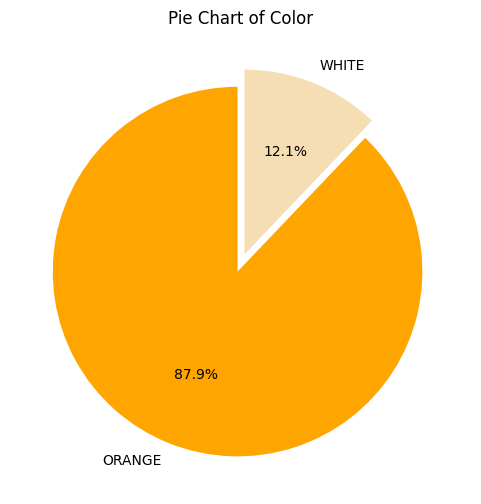

In [91]:
plot_pie_chart(df_cleaned, "Color")

In [92]:
columns = ["Origin","Sub Variety","Package","City Name", "Repack", "Item Size", "Variety"]
for col in columns:
    table = pd.crosstab(df_cleaned['Color'], df_cleaned[col])
    chi2, p, dof, expected = chi2_contingency(table)
    print(f"Chi-square p-value: {p}")

Chi-square p-value: 1.7735502576384136e-12
Chi-square p-value: 3.2193972987123464e-06
Chi-square p-value: 2.827492900964126e-49
Chi-square p-value: 3.3145767726090518e-12
Chi-square p-value: 0.8842006796816114
Chi-square p-value: 3.637839649266885e-23
Chi-square p-value: 5.875228373325115e-145


In [93]:
y = df_cleaned["Color"]

X = df_cleaned.drop(columns=["Color", "Date", "Low Price","High Price","Mostly Low","Mostly High","Repack"])

In [94]:
le = LabelEncoder()

y_encoded = le.fit_transform(y)

print(dict(zip(le.classes_, le.transform(le.classes_))))

{'ORANGE': np.int64(0), 'WHITE': np.int64(1)}


In [95]:
categorical_cols = ["Origin","Sub Variety","Package","City Name","Variety"]
item_size_categories = [['sml', 'med', 'med-lge', 'lge', 'xlge', 'jbo', 'exjbo']]
ordinal_features = ['Item Size']
print("Categorical columns:", categorical_cols)


ct = ColumnTransformer(
    transformers=[
        ("onehot", OneHotEncoder(sparse_output=False), categorical_cols),
        ("ordinal", OrdinalEncoder(categories=item_size_categories),ordinal_features)
    ],
    remainder="passthrough"
)

X_encoded = ct.fit_transform(X)
print("Encoded shape:", X_encoded.shape)
print("Feature names:", len(ct.get_feature_names_out()))


Categorical columns: ['Origin', 'Sub Variety', 'Package', 'City Name', 'Variety']
Encoded shape: (1757, 65)
Feature names: 65


In [96]:
print(type(X_encoded))

<class 'numpy.ndarray'>


In [97]:
X_encoded

array([[0., 0., 0., ..., 0., 0., 3.],
       [0., 0., 0., ..., 0., 0., 3.],
       [0., 0., 0., ..., 0., 0., 1.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], shape=(1757, 65))

In [98]:
#Normalise the dataset
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X_encoded)
X_scaled

array([[-0.04776822, -0.37636475, -0.22686161, ..., -0.18311038,
        -0.60255469,  0.72635197],
       [-0.04776822, -0.37636475, -0.22686161, ..., -0.18311038,
        -0.60255469,  0.72635197],
       [-0.04776822, -0.37636475, -0.22686161, ..., -0.18311038,
        -0.60255469, -0.42286047],
       ...,
       [-0.04776822, -0.37636475, -0.22686161, ..., -0.18311038,
        -0.60255469, -0.99746669],
       [-0.04776822, -0.37636475, -0.22686161, ..., -0.18311038,
        -0.60255469, -0.99746669],
       [-0.04776822, -0.37636475, -0.22686161, ..., -0.18311038,
        -0.60255469, -0.99746669]], shape=(1757, 65))

In [101]:
# Splitting dataset into train and test
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_encoded, test_size=0.2, train_size=0.8, random_state=42
)

In [102]:
lr = LogisticRegression()

In [103]:
lr.fit(X_train, y_train)

y_pred = lr.predict(X_test)

In [104]:
y_pred

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0,
       0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0,
       0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0,
       1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0,
       0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,

In [105]:
y_test

array([0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0,
       1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0,
       0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0,
       1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 1, 0,
       0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,

In [106]:
# Accuracy score of our model
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy score: {accuracy: .2f}")

Accuracy score:  0.91


In [107]:
# Classification report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.93      0.97      0.95       306
           1       0.73      0.52      0.61        46

    accuracy                           0.91       352
   macro avg       0.83      0.75      0.78       352
weighted avg       0.90      0.91      0.91       352



In [108]:
print(confusion_matrix(y_test, y_pred))

[[297   9]
 [ 22  24]]
